# 4.2 — Arbres sklearn

Cette famille regroupe les modèles **basés sur des arbres** disponibles dans scikit-learn. Tous partagent l'**invariance par transformation monotone** : un arbre coupe sur des seuils, donc multiplier ou décaler une feature ne change rien. → on consomme **`preprocessor_encoded`** (impute + encode, **pas** de StandardScaler — opération inutile).

| Modèle              | Hypothèse principale                                                                                          |
|---------------------|---------------------------------------------------------------------------------------------------------------|
| DecisionTree        | Splits axis-aligned suffisent à approximer la fonction-cible ; tendance forte au surapprentissage             |
| RandomForest        | Bagging : la diversité des arbres décorrélés réduit la variance                                                |
| GradientBoosting    | Boosting séquentiel : chaque arbre apprend les pseudo-résidus du précédent                                    |
| AdaBoost            | Re-pondération des erreurs à chaque itération — sensible aux étiquettes bruitées                              |

In [1]:
%load_ext autoreload
%autoreload 2
%run 2_data_prep.ipynb

Dimensions brutes : (1460, 81)
Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)
Variables après ingénierie : 90 colonnes (+8 dérivées)
Corrélation des variables dérivées avec SalePrice_log :
  TotalSF            : +0.825
  TotalBathrooms     : +0.677
  HouseAge           : -0.588
  YearsSinceRemodel  : -0.569
  GarageAge          : -0.543
  HasGarage          : +0.323
  HasSecondFloor     : +0.151
  HasPool            : +0.077   <-- faible (|r| < 0.1)
X_train : (1166, 83)   |   X_test : (292, 83)
Colonnes retirées (colinéarité) : ['GarageArea', 'TotalBsmtSF', 'TotRmsAbvGrd', 'GarageYrBlt']
NaN dans X_train : 6276 cellules sur 96778
Audit de cardinalité des colonnes nominales (sur X_train) :
Colonne           modalités   bucket
  Neighborhood           25     TargetEncoder (haute)  [imput. mode]
  Exterior2nd            16     TargetEncoder (haute)  [imput. mode]
  Exterior1st            15     TargetEncoder (haute)  [imput. mode]
  MSSubClass             15     

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

FAMILY = 'sklearn_trees'

## 4.2.1 Decision Tree — avec courbe d'overfitting

### Hypothèses du modèle
- **Aucune hypothèse paramétrique** sur la distribution. Le partitionnement axis-aligned est universellement consistant si l'arbre est assez profond.
- Hypothèse implicite : la fonction-cible se décompose bien en **règles rectangulaires** dans l'espace des features.
- **Forte tendance au surapprentissage** : sans contrainte de profondeur, un arbre profond mémorise les données d'entraînement.

On balaye `max_depth` et on trace train R² vs CV R² (exigence du cours 04_Overfitting).

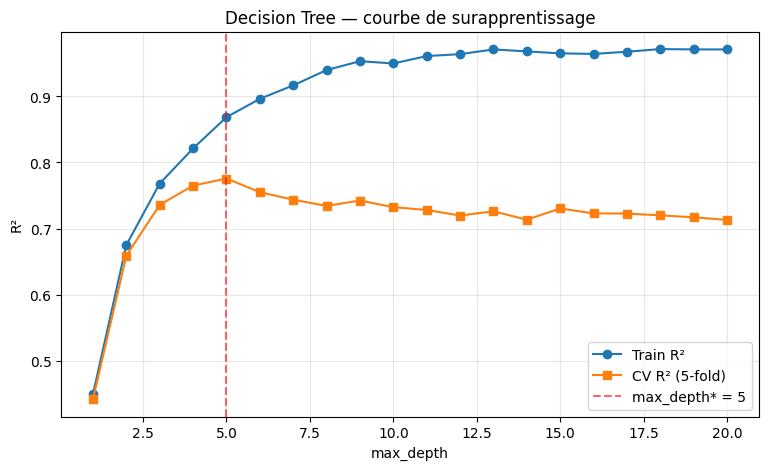

Profondeur optimale (CV R² max) : 5
L'écart train-vs-CV à droite illustre le surapprentissage : à max_depth élevé, le train R² → 1 mais le CV R² stagne / décroît.


In [3]:
depth_range = list(range(1, 21))
train_scores, cv_scores = [], []

for d in depth_range:
    pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train_log)
    train_scores.append(pipe.score(X_train, y_train_log))
    cv_scores.append(cross_val_score(pipe, X_train, y_train_log, cv=5, scoring='r2', n_jobs=-1).mean())

best_depth = int(depth_range[int(np.argmax(cv_scores))])

plt.figure(figsize=(9, 5))
plt.plot(depth_range, train_scores, marker='o', label='Train R²')
plt.plot(depth_range, cv_scores, marker='s', label='CV R² (5-fold)')
plt.axvline(best_depth, color='red', ls='--', alpha=0.6, label=f'max_depth* = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Decision Tree — courbe de surapprentissage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Profondeur optimale (CV R² max) : {best_depth}")
print(f"L'écart train-vs-CV à droite illustre le surapprentissage : à max_depth élevé, le train R² → 1 mais le CV R² stagne / décroît.")

DecisionTree — CV RMSLE: 0.1870   Holdout RMSLE: 0.1798   max_depth: 5   fit_time: 0.06s


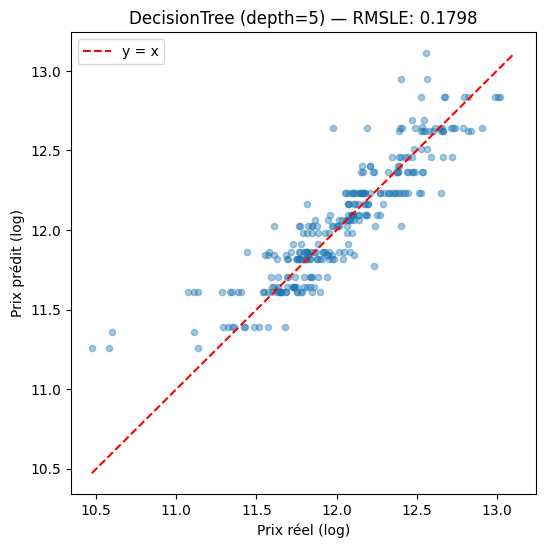

PosixPath('results/family_sklearn_trees.json')

In [4]:
t0 = time.time()
dt_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))])
dt_pipe.fit(X_train, y_train_log)
dt_fit_s = time.time() - t0
dt_pred = dt_pipe.predict(X_test)
dt_holdout = rmsle_score(y_test_log, dt_pred)
dt_cv = cv_rmsle(dt_pipe, X_train, y_train_log)

print(f"DecisionTree — CV RMSLE: {dt_cv:.4f}   Holdout RMSLE: {dt_holdout:.4f}   max_depth: {best_depth}   fit_time: {dt_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, dt_pred, title=f"DecisionTree (depth={best_depth}) — RMSLE: {dt_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'DecisionTree', cv_rmsle=dt_cv, holdout_rmsle=dt_holdout, fit_time_s=dt_fit_s, params={'max_depth': best_depth})

## 4.2.2 Random Forest — bagging d'arbres

### Hypothèses du modèle
- Hypothèse de **bagging** : moyenner les prédictions de nombreux arbres décorrélés réduit la variance sans augmenter le biais.
- La décorrélation vient (1) du bootstrap des observations et (2) du sous-échantillonnage des features à chaque split.
- Robuste aux outliers et aux features non pertinentes.
- Limite : ne fait pas mieux que le meilleur arbre individuel sur un signal très complexe — pour ça il faut le **boosting**.

RandomForest — CV RMSLE: 0.1368   Holdout RMSLE: 0.1378   fit_time: 1.69s


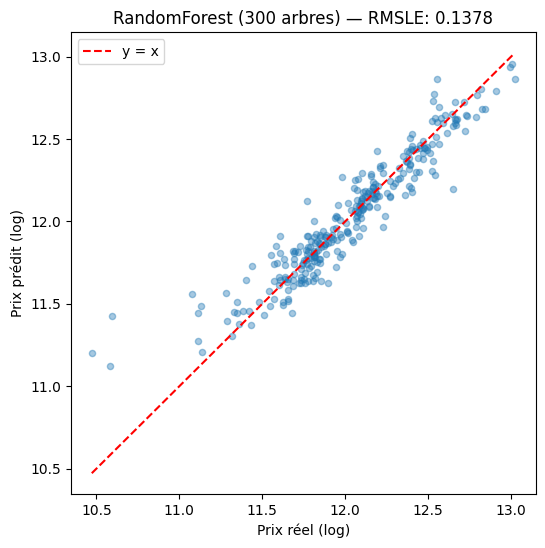

PosixPath('results/family_sklearn_trees.json')

In [5]:
t0 = time.time()
rf_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(X_train, y_train_log)
rf_fit_s = time.time() - t0
rf_pred = rf_pipe.predict(X_test)
rf_holdout = rmsle_score(y_test_log, rf_pred)
rf_cv = cv_rmsle(rf_pipe, X_train, y_train_log)

print(f"RandomForest — CV RMSLE: {rf_cv:.4f}   Holdout RMSLE: {rf_holdout:.4f}   fit_time: {rf_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, rf_pred, title=f"RandomForest (300 arbres) — RMSLE: {rf_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'RandomForest', cv_rmsle=rf_cv, holdout_rmsle=rf_holdout, fit_time_s=rf_fit_s, params={'n_estimators': 300})

## 4.2.3 Gradient Boosting

### Hypothèses du modèle
- Hypothèse de **boosting séquentiel** : chaque arbre apprend les pseudo-résidus (gradient de la perte) du modèle courant.
- Combine biais faible (capacité d'addition d'arbres) et variance contrôlée (learning rate).
- Plus sensible que RF à des hyperparamètres mal réglés (`learning_rate` × `n_estimators` doit être équilibré).
- Plus lent à entraîner que RF mais souvent meilleur.

GradientBoosting — CV RMSLE: 0.1252   Holdout RMSLE: 0.1154   fit_time: 2.76s


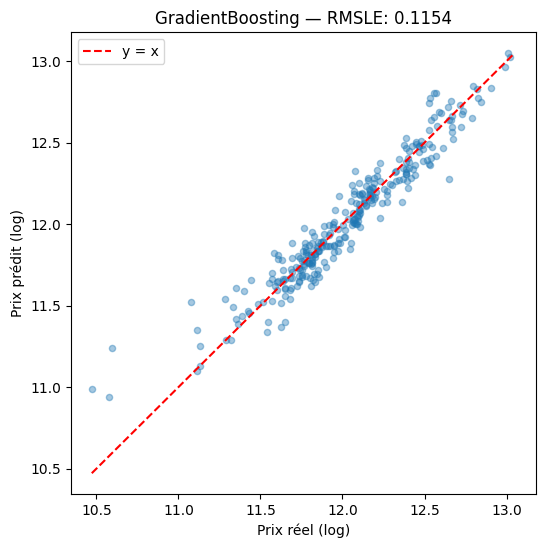

PosixPath('results/family_sklearn_trees.json')

In [6]:
t0 = time.time()
gb_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE))])
gb_pipe.fit(X_train, y_train_log)
gb_fit_s = time.time() - t0
gb_pred = gb_pipe.predict(X_test)
gb_holdout = rmsle_score(y_test_log, gb_pred)
gb_cv = cv_rmsle(gb_pipe, X_train, y_train_log)

print(f"GradientBoosting — CV RMSLE: {gb_cv:.4f}   Holdout RMSLE: {gb_holdout:.4f}   fit_time: {gb_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, gb_pred, title=f"GradientBoosting — RMSLE: {gb_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'GradientBoosting', cv_rmsle=gb_cv, holdout_rmsle=gb_holdout, fit_time_s=gb_fit_s,
               params={'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3})

## 4.2.4 AdaBoost

### Hypothèses du modèle
- Hypothèse de **boosting par re-pondération** : à chaque itération, les observations mal prédites reçoivent un poids supérieur.
- Original (Freund & Schapire 1997) — antérieur à Gradient Boosting.
- **Sensibilité aux outliers et au bruit** : les observations difficiles à prédire (qui peuvent être du bruit, pas un signal apprenable) voient leur poids exploser → AdaBoost peut sur-apprendre du bruit.
- Notre filtre d'outliers (3.2 du prep) limite ce risque, mais AdaBoost reste généralement moins performant que GB sur cette tâche.

AdaBoost — CV RMSLE: 0.1592   Holdout RMSLE: 0.1697   fit_time: 1.65s


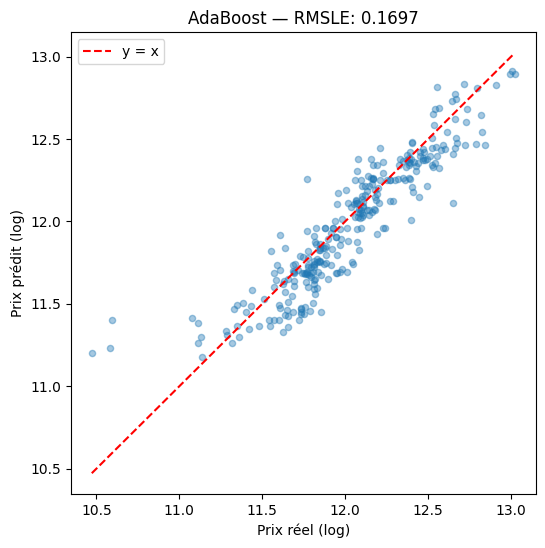

PosixPath('results/family_sklearn_trees.json')

In [7]:
t0 = time.time()
ada_pipe = Pipeline([('preprocessor', preprocessor_encoded), ('model', AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE))])
ada_pipe.fit(X_train, y_train_log)
ada_fit_s = time.time() - t0
ada_pred = ada_pipe.predict(X_test)
ada_holdout = rmsle_score(y_test_log, ada_pred)
ada_cv = cv_rmsle(ada_pipe, X_train, y_train_log)

print(f"AdaBoost — CV RMSLE: {ada_cv:.4f}   Holdout RMSLE: {ada_holdout:.4f}   fit_time: {ada_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ada_pred, title=f"AdaBoost — RMSLE: {ada_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'AdaBoost', cv_rmsle=ada_cv, holdout_rmsle=ada_holdout, fit_time_s=ada_fit_s, params={'n_estimators': 200})

## 4.2.5 Comparaison intra-famille

On compare les RMSLE des arbres scikit-learn pour désigner le **champion de famille**. La modélisation se poursuit ensuite avec le **boosting moderne à gestion native** (`3c`) — XGBoost, LightGBM, CatBoost — qui gèrent nativement les valeurs manquantes et les catégorielles.

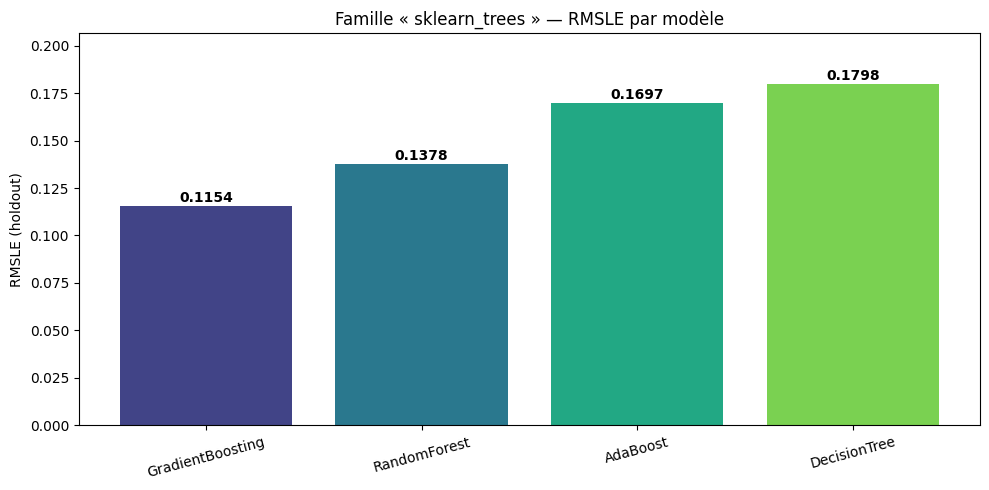

,model,cv_rmsle,holdout_rmsle,fit_time_s
0,GradientBoosting,0.125168,0.115419,2.757908
1,RandomForest,0.136849,0.137788,1.686232
2,AdaBoost,0.159186,0.169745,1.650367
3,DecisionTree,0.187021,0.179759,0.058734


In [8]:
family_path = RESULTS_DIR / f'family_{FAMILY}.json'
fam = pd.DataFrame(json.loads(family_path.read_text()))
fam = fam.sort_values('holdout_rmsle').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fam['model'], fam['holdout_rmsle'], color=sns.color_palette('viridis', len(fam)))
for bar, v in zip(bars, fam['holdout_rmsle']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax.set_ylabel('RMSLE (holdout)')
ax.set_title("Famille « sklearn_trees » — RMSLE par modèle")
ax.set_ylim(0, fam['holdout_rmsle'].max() * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(fam[['model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s']])

In [9]:
# Sauvegarde des prédictions holdout pour la grille prédit-vs-réel de 4_evaluation
np.savez(
    RESULTS_DIR / f'preds_{FAMILY}.npz',
    y_true=y_test_log.values,
    DecisionTree=dt_pred, RandomForest=rf_pred,
    GradientBoosting=gb_pred, AdaBoost=ada_pred,
)
print(f"Prédictions holdout sauvegardées : {RESULTS_DIR / f'preds_{FAMILY}.npz'}")

Prédictions holdout sauvegardées : results/preds_sklearn_trees.npz
